# Word2Vec — Skip-gram (TensorFlow)

Ce notebook entraîne **Word2Vec Skip-gram** avec **negative sampling** sur `text8`,
puis calcule les similarités et analogies (comme demandé dans le TP).

In [6]:
# === 1) Imports & config ===
import os, re, json, math, time, random
from pathlib import Path
import numpy as np
import tensorflow as tf
from collections import Counter


In [10]:
# === 2) Chargement vocab/dataset si disponibles ===
from pathlib import Path
ARTIFACTS = Path("C:/Users/223114186/Desktop/TP3_Word Embeddings/artifact")
vocab_json = ARTIFACTS / 'vocab_mappings.json'
dataset_npz = ARTIFACTS / 'text8_dataset.npz'

word2id = None; id2word = None; vocab = None
ids = None; window = 2; unk_id = None

if vocab_json.exists():
    with open(vocab_json, 'r', encoding='utf-8') as f:
        voc_data = json.load(f)
    vocab = voc_data.get('vocab', None)
    word2id = {k:int(v) for k,v in voc_data['word2id'].items()}
    id2word = {int(k):v for k,v in voc_data['id2word'].items()}
    print('✅ vocab mappings chargés')
else:
    print('⚠️ vocab_mappings.json non trouvé — on pourra reconstruire si nécessaire.')

if dataset_npz.exists():
    data = np.load(dataset_npz, allow_pickle=True)
    if 'ids' in data.files:
        ids = data['ids'].astype(np.int32)
        print('✅ ids chargés depuis text8_dataset.npz')
    if 'window' in data.files:
        window = int(data['window'])
    if 'unk_id' in data.files:
        unk_id = int(data['unk_id'])
    print('window =', window, ' unk_id =', unk_id)
else:
    print('⚠️ text8_dataset.npz non trouvé — on reconstruira ids à partir du texte.')


✅ vocab mappings chargés
window = 2  unk_id = 31167


In [14]:
# === 3) Reconstruction ids à partir du texte (si nécessaire) ===
import nltk, re
from nltk.corpus import stopwords
nltk.download('punkt', quiet=True)

DATA_DIR = Path("C:/Users/223114186/Desktop/TP3_Word Embeddings/data")
TEXT_PATH = DATA_DIR / 'text8.text'

if ids is None or word2id is None:
    #text_path = find_file(TEXT8_NAME, DATA_DIR)
    #assert text_path is not None, f"Fichier {TEXT8_NAME} introuvable dans {DATA_DIR}."
    print('Lecture texte depuis :', TEXT_PATH)

    raw = Path(TEXT_PATH).read_text(encoding='utf-8', errors='ignore').lower()
    text = re.sub(r'[^a-z\s]', ' ', raw)
    text = re.sub(r'\s+', ' ', text).strip()
    tokens = nltk.word_tokenize(text)

    # Construire vocab minimal si absent (min_freq=5 par défaut)
    min_freq = 5
    if word2id is None:
        freq = Counter(tokens)
        vocab = sorted([w for w,c in freq.items() if c >= min_freq])
        word2id = {w:i for i,w in enumerate(vocab)}
        id2word = {i:w for w,i in word2id.items()}
        print('Vocab reconstruit (min_freq=5) — size =', len(vocab))

    unk_id = len(word2id)
    ids = np.array([word2id.get(w, unk_id) for w in tokens], dtype=np.int32)
    print('len(ids) =', len(ids), '   unk_id =', unk_id)


Lecture texte depuis : C:\Users\223114186\Desktop\TP3_Word Embeddings\data\text8.text
len(ids) = 3816142    unk_id = 31167


In [16]:
# === 4) Subsampling à la Mikolov + génération paires skip-gram ===
t = 1e-5  # plus petit => plus d'agressivité sur mots fréquents
vocab_size = len(word2id) + 1  # + UNK

# Comptes par id
counts = np.bincount(ids, minlength=vocab_size).astype(np.float64)
total = counts.sum()
freq = counts / max(total, 1.0)
keep_prob = np.minimum(1.0, (np.sqrt(freq / t) + 1.0) * (t / (freq + 1e-12)))
SEED = 42
rng = np.random.default_rng(SEED)
ids_sub = [int(wid) for wid in ids if rng.random() < keep_prob[wid]]
print('Taille avant/après subsampling :', len(ids), '→', len(ids_sub))

# Génération paires (target -> context) pour window
pairs = []
w = window
for i in range(w, len(ids_sub) - w):
    tgt = ids_sub[i]
    if tgt == unk_id:  # ignorer UNK en cible
        continue
    ctx = ids_sub[i-w:i] + ids_sub[i+1:i+1+w]
    for c in ctx:
        if c != unk_id:
            pairs.append((tgt, c))

pairs = np.array(pairs, dtype=np.int32)
X_tgt = pairs[:, 0]
y_ctx = pairs[:, 1]
print('Nb paires =', len(pairs))


Taille avant/après subsampling : 3816142 → 1119637
Nb paires = 4417528


In [17]:
# === 5) Dataset TensorFlow ===
BATCH = 8192
AUTOTUNE = tf.data.AUTOTUNE

ds = tf.data.Dataset.from_tensor_slices((X_tgt, y_ctx)) \
    .shuffle(min(len(X_tgt), 1_000_000), reshuffle_each_iteration=True) \
    .batch(BATCH) \
    .prefetch(AUTOTUNE)

print(ds)


<_PrefetchDataset element_spec=(TensorSpec(shape=(None,), dtype=tf.int32, name=None), TensorSpec(shape=(None,), dtype=tf.int32, name=None))>


In [19]:
# === 6) Skip-gram w/ sampled_softmax + unigram^0.75 sampler (FIX) ===
embed_dim  = 128
num_neg    = 20

# Tables d'embeddings
W_in  = tf.Variable(tf.random.normal([vocab_size, embed_dim], stddev=0.01))
W_out = tf.Variable(tf.random.normal([vocab_size, embed_dim], stddev=0.01))

# Distribution unigram^0.75 en LISTE Python
alpha = 0.75
unigrams = np.power(counts, alpha)
unigrams = unigrams / (unigrams.sum() + 1e-12)
unigrams_list = [float(x) for x in unigrams.tolist()]  # <-- list Python

# IMPORTANT : capturer des *ints Python* en dehors du @tf.function
vocab_size_py = int(vocab_size)
num_neg_py    = int(num_neg)

# Optimiseur + LR schedule
lr_schedule = tf.keras.optimizers.schedules.ExponentialDecay(
    initial_learning_rate=5e-4, decay_steps=2000, decay_rate=0.95, staircase=True
)
optimizer = tf.keras.optimizers.Adam(learning_rate=lr_schedule)

@tf.function
def train_step(tgt, ctx):
    with tf.GradientTape() as tape:
        # (B, D)
        v_t = tf.nn.embedding_lookup(W_in, tgt)

        # Sampler négatifs : NOTE -> range_max et unigrams doivent être des types Python (pas Tensors)
        sampled_values = tf.random.fixed_unigram_candidate_sampler(
            true_classes=tf.cast(tf.expand_dims(ctx, 1), tf.int64),
            num_true=1,
            num_sampled=num_neg_py,    # <-- int Python
            unique=True,
            range_max=vocab_size_py,   # <-- int Python
            unigrams=unigrams_list     # <-- liste Python
        )

        loss = tf.reduce_mean(tf.nn.sampled_softmax_loss(
            weights=W_out,                                       # (V, D)
            biases=tf.zeros([vocab_size_py], dtype=tf.float32),
            labels=tf.expand_dims(tf.cast(ctx, tf.int64), 1),    # (B,1)
            inputs=v_t,                                          # (B,D)
            num_sampled=num_neg_py,
            num_classes=vocab_size_py,
            sampled_values=sampled_values
        ))

    grads = tape.gradient(loss, [W_in, W_out])
    grads, _ = tf.clip_by_global_norm(grads, 5.0)
    optimizer.apply_gradients(zip(grads, [W_in, W_out]))
    return loss

# Entraînement
BATCH = 8192
ds = tf.data.Dataset.from_tensor_slices((X_tgt, y_ctx)) \
      .shuffle(min(len(X_tgt), 1_000_000), reshuffle_each_iteration=True) \
      .batch(BATCH).prefetch(tf.data.AUTOTUNE)
loss_history = []
EPOCHS = 6
for epoch in range(1, EPOCHS+1):
    t0 = time.time()
    for step, (bt_tgt, bt_ctx) in enumerate(ds):
        loss = train_step(bt_tgt, bt_ctx)
        loss_history.append(float(loss))
        if (step+1) % 200 == 0:
            tf.print('epoch', epoch, 'step', step+1, 'loss', loss)
    dt = time.time() - t0
    tf.print('EPOCH', epoch, 'DONE  last loss:', loss, ' time(s)=', dt)


epoch 1 step 200 loss 3.25259256
epoch 1 step 400 loss 3.51130342
EPOCH 1 DONE  last loss: 3.11943293  time(s)= 34.12288522720337
epoch 2 step 200 loss 3.24666476
epoch 2 step 400 loss 2.92230678
EPOCH 2 DONE  last loss: 3.25160384  time(s)= 32.772956132888794
epoch 3 step 200 loss 3.40071082
epoch 3 step 400 loss 3.29024792
EPOCH 3 DONE  last loss: 3.12734818  time(s)= 31.950348138809204
epoch 4 step 200 loss 3.20846748
epoch 4 step 400 loss 3.24215579
EPOCH 4 DONE  last loss: 3.15985179  time(s)= 32.30033802986145
epoch 5 step 200 loss 3.18356943
epoch 5 step 400 loss 3.47158456
EPOCH 5 DONE  last loss: 3.04512572  time(s)= 32.699257373809814
epoch 6 step 200 loss 2.90114355
epoch 6 step 400 loss 3.04181695
EPOCH 6 DONE  last loss: 2.77935529  time(s)= 32.78352880477905


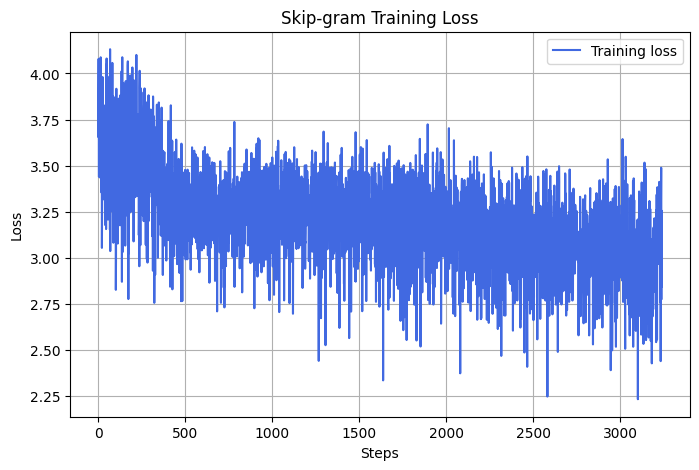

In [21]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.plot(loss_history, label="Training loss", color="royalblue")
plt.xlabel("Steps")
plt.ylabel("Loss")
plt.title("Skip-gram Training Loss")
plt.legend()
plt.grid(True)
plt.show()

In [20]:
# === 7) Similarités & analogies ===
E = W_in.numpy().astype(np.float32)
E_norm = E / (np.linalg.norm(E, axis=1, keepdims=True) + 1e-9)

def topk_similar(word, k=10):
    wid = word2id.get(word)
    if wid is None:
        return []
    v = E_norm[wid]
    sims = E_norm @ v
    idx = np.argpartition(-sims, range(k+1))[:k+1]
    idx = idx[np.argsort(-sims[idx])]
    out = []
    for i in idx:
        if i == wid:
            continue
        out.append((id2word.get(int(i), '<UNK>'), float(sims[i])))
        if len(out) == k:
            break
    return out

def similar_by_vector(vec, k=10):
    vec = np.asarray(vec, dtype=np.float32)
    vec = vec / (np.linalg.norm(vec) + 1e-9)
    sims = E_norm @ vec
    idx = np.argpartition(-sims, range(k))[:k]
    idx = idx[np.argsort(-sims[idx])]
    return [(id2word.get(int(i), '<UNK>'), float(sims[i])) for i in idx]

def analogy(a, b, c, k=10):
    if any(w not in word2id for w in (a,b,c)):
        missing = [w for w in (a,b,c) if w not in word2id]
        raise ValueError(f"Mots absents du vocab: {missing}")
    vec = E[word2id[a]] - E[word2id[b]] + E[word2id[c]]
    return similar_by_vector(vec, k=k)

# Sanity checks
row_norms = np.linalg.norm(E, axis=1)
print('Norme moyenne des vecteurs :', row_norms.mean(), '±', row_norms.std())

rng = np.random.default_rng(0)
sample_ids = rng.choice(E.shape[0], size=min(200, E.shape[0]), replace=False)
S = (E_norm[sample_ids] @ E_norm.T)
S = S[:, ~np.isin(np.arange(E.shape[0]), sample_ids)]
print('Cosine ~ moy:', S.mean(), 'std:', S.std())

print('\nVoisins de \'man\':')
for w, s in topk_similar('man', 10): print(f"{w:<15} {s:.4f}")

print('\nAnalogie: king - man + woman ≈ ?')
for w, s in analogy('king', 'man', 'woman', 10): print(f"{w:<15} {s:.4f}")


Norme moyenne des vecteurs : 0.9644047 ± 0.39147237
Cosine ~ moy: 0.16657326 std: 0.3472155

Voisins de 'man':
told            0.8979
glory           0.8893
refuses         0.8867
curse           0.8800
evil            0.8779
love            0.8725
afraid          0.8710
tell            0.8672
disguise        0.8592
hearts          0.8581

Analogie: king - man + woman ≈ ?
king            0.9135
sons            0.8818
constantine     0.8648
son             0.8511
jeroboam        0.8478
reign           0.8423
emperor         0.8402
gundobad        0.8374
rome            0.8335
abiathar        0.8325


In [16]:
# === 8) Sauvegarde des artefacts ===
np.savez(ARTIFACTS / 'skipgram_embeddings.npz', E=E)
with open(ARTIFACTS / 'vocab_mappings.json', 'w', encoding='utf-8') as f:
    json.dump({'word2id': word2id, 'id2word': {int(k):v for k,v in id2word.items()}, 'vocab': vocab}, f)
print('✅ Embeddings et vocab sauvegardés dans', ARTIFACTS.resolve())


✅ Embeddings et vocab sauvegardés dans C:\Users\223114186\Desktop\TP3_Word Embeddings\artifact
